In [3]:
# Import the Dependencies and Load the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# File path (use raw string to avoid path errors)
file_path = r"C:\Users\sagni\Downloads\AAPL_stock_data.xlsx"

# Load Excel file
df = pd.read_excel(file_path)

# View first few rows
print(df.head())

                 Price      Close       High        Low       Open     Volume
0               Ticker       AAPL       AAPL       AAPL       AAPL       AAPL
1                 Date        NaN        NaN        NaN        NaN        NaN
2  2020-01-02 00:00:00  72.400513  72.460776  71.156674  71.409778  135480400
3  2020-01-03 00:00:00  71.696632   72.45595  71.472454  71.629138  146322800
4  2020-01-06 00:00:00  72.267929  72.306499  70.568503  70.819201  118387200


In [5]:

# Step 1, ETL, Extract, Transform and Load the Data ( data Cleaning)
# Fix structure (remove incorrect header rows)
df = df.iloc[2:]   # drop first 2 rows
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Reset index
df = df.reset_index(drop=True)

#  Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ============================
# DATA ISSUES CHECK
# ============================

print("🔹 Missing Values:\n")
print(df.isnull().sum())

print("\n🔹 Duplicate Dates:\n")
print(df.duplicated(subset='Date').sum())

print("\n🔹 Data Types:\n")
print(df.dtypes)

🔹 Missing Values:

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

🔹 Duplicate Dates:

0

🔹 Data Types:

Date      datetime64[ns]
Close             object
High              object
Low               object
Open              object
Volume            object
dtype: object


In [7]:
# Data Cleaning Continues
# Convert columns to numeric
cols = ['Close', 'High', 'Low', 'Open', 'Volume']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check again
print("\n🔹 Updated Data Types:\n")
print(df.dtypes)

print("\n🔹 Missing Values After Conversion:\n")
print(df.isnull().sum())


🔹 Updated Data Types:

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

🔹 Missing Values After Conversion:

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


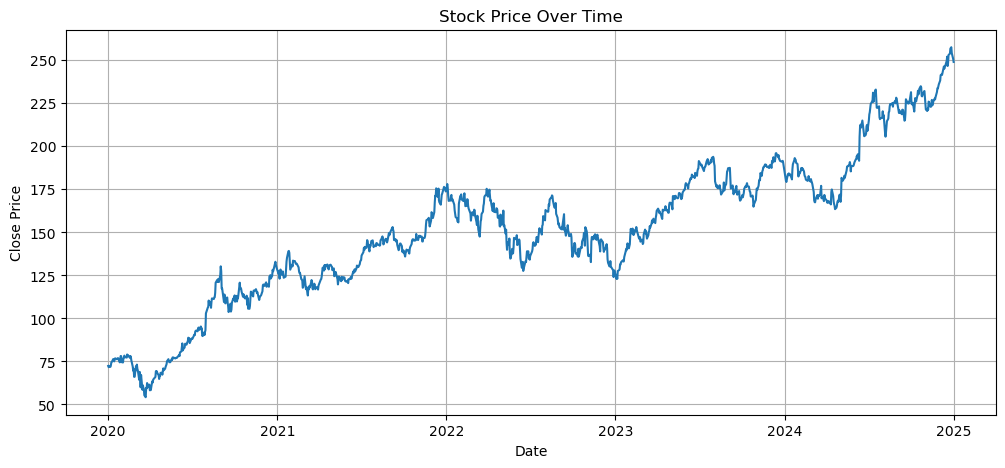

🔹 Returns Summary:
count    1257.000000
mean        0.000983
std         0.019940
min        -0.137708
25%        -0.008460
50%         0.001186
75%         0.011918
max         0.113157
Name: returns, dtype: float64


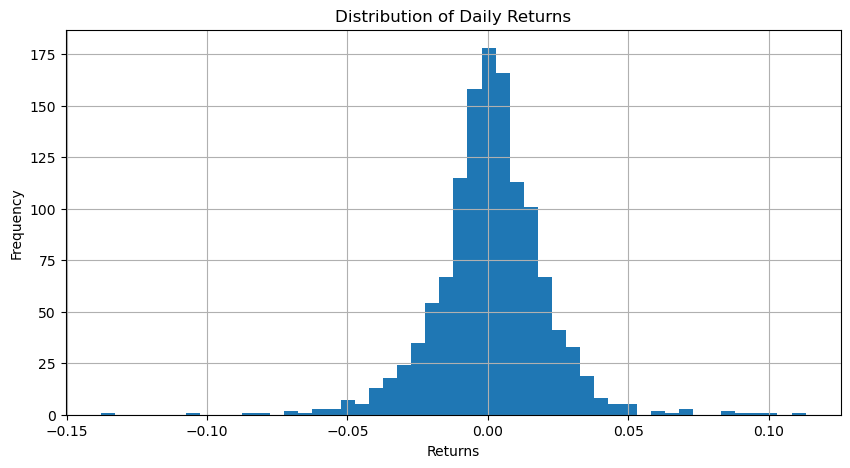

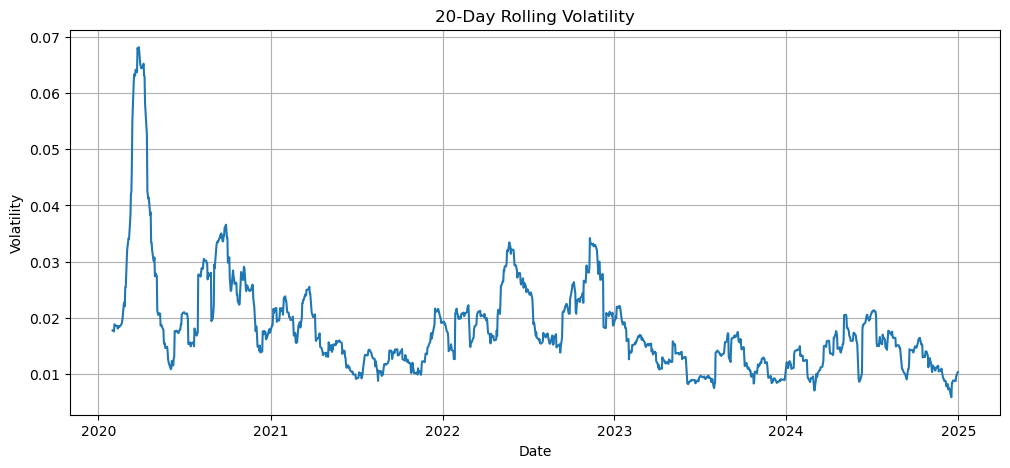

In [11]:
# Step 2,Exploratory Data Analysis (EDA – Understanding the Market)
# =========================
# (a) PRICE BEHAVIOR
# =========================

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title('Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


# =========================
# (b) RETURNS DISTRIBUTION
# =========================

# Compute log returns
df['returns'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop NaN (first value)
returns = df['returns'].dropna()

# Summary stats
print("🔹 Returns Summary:")
print(returns.describe())

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(returns, bins=50)
plt.title('Distribution of Daily Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# =========================
# (c) VOLATILITY BEHAVIOR
# =========================

# Rolling volatility (20-day)
df['volatility'] = df['returns'].rolling(window=20).std()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['volatility'])
plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()

In [13]:
# Step 3, Feature Engineering (Turning Data into Signals)

# =========================
# (a) DAILY RETURNS (Log Returns)
# =========================
df['returns'] = np.log(df['Close'] / df['Close'].shift(1))

# =========================
# (b) ROLLING VOLATILITY (20-day)
# =========================
df['volatility_20'] = df['returns'].rolling(window=20).std()

# =========================
# (c) MOMENTUM INDICATORS
# =========================

# 10-day momentum (log return)
df['momentum_10'] = np.log(df['Close'] / df['Close'].shift(10))

# 20-day momentum (log return)
df['momentum_20'] = np.log(df['Close'] / df['Close'].shift(20))

# =========================
# CLEAN DATA (drop NaN created due to shifting)
# =========================
df = df.dropna().reset_index(drop=True)

# =========================
# CHECK OUTPUT
# =========================
print(df[['Date', 'Close', 'returns', 'volatility_20', 'momentum_10', 'momentum_20']].head())


        Date      Close   returns  volatility_20  momentum_10  momentum_20
0 2020-01-31  74.608566 -0.045352       0.017787    -0.018344     0.030042
1 2020-02-03  74.403671 -0.002750       0.017621    -0.032104     0.037062
2 2020-02-04  76.860008  0.032480       0.018877     0.007176     0.061605
3 2020-02-05  77.486763  0.008121       0.018816     0.011735     0.074441
4 2020-02-06  78.393143  0.011629       0.018692     0.018560     0.070112


🔹 Autocorrelation of Returns (Lag 1):
-0.11241215187117062


<Figure size 1000x400 with 0 Axes>

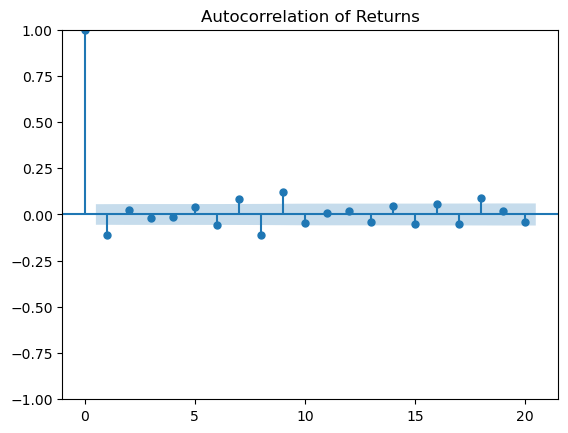


🔹 Autocorrelation of Squared Returns (Lag 1):
0.3294855053033552


<Figure size 1000x400 with 0 Axes>

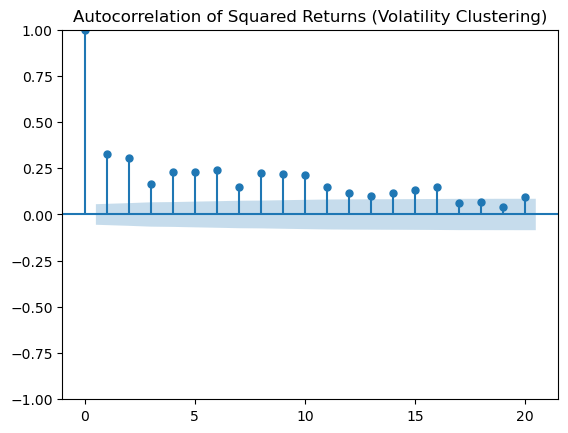


🔹 Momentum Persistence (Return vs Lagged Return Correlation):
-0.11241215187117057


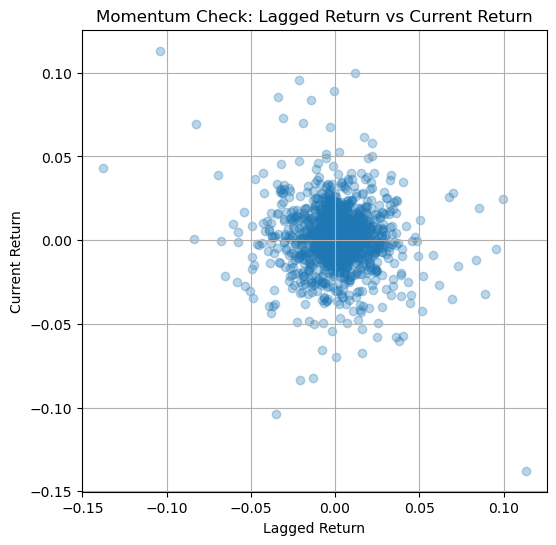

In [15]:
# Step 4, Identify Statistical Patterns, Auto Correlation, Volatility clustering, Momentum persistence

from statsmodels.graphics.tsaplots import plot_acf

# =========================
# 1. AUTOCORRELATION (Returns)
# =========================

print("🔹 Autocorrelation of Returns (Lag 1):")
print(df['returns'].autocorr(lag=1))

# Plot ACF for returns
plt.figure(figsize=(10,4))
plot_acf(df['returns'], lags=20)
plt.title('Autocorrelation of Returns')
plt.show()


# =========================
# 2. VOLATILITY CLUSTERING
# =========================

# Use squared returns as proxy for volatility clustering
df['returns_sq'] = df['returns']**2

print("\n🔹 Autocorrelation of Squared Returns (Lag 1):")
print(df['returns_sq'].autocorr(lag=1))

# Plot ACF for squared returns
plt.figure(figsize=(10,4))
plot_acf(df['returns_sq'], lags=20)
plt.title('Autocorrelation of Squared Returns (Volatility Clustering)')
plt.show()


# =========================
# 3. MOMENTUM PERSISTENCE
# =========================

# Correlation between today's return and past return (lagged)
df['returns_lag1'] = df['returns'].shift(1)

momentum_corr = df[['returns', 'returns_lag1']].corr().iloc[0,1]

print("\n🔹 Momentum Persistence (Return vs Lagged Return Correlation):")
print(momentum_corr)


# =========================
# OPTIONAL: VISUAL CHECK
# =========================

plt.figure(figsize=(6,6))
plt.scatter(df['returns_lag1'], df['returns'], alpha=0.3)
plt.title('Momentum Check: Lagged Return vs Current Return')
plt.xlabel('Lagged Return')
plt.ylabel('Current Return')
plt.grid(True)
plt.show()

In [23]:
# Step 5, Build Alpha Signals (Core Idea), Momentum, Volatility, combined
# =========================
# BUILD ALPHA SIGNALS
# =========================

# 🔹 (1) Momentum Signal
# If 10-day momentum > 0 → Buy (1), else Sell (-1)
df['signal_momentum'] = np.where(df['momentum_10'] > 0, 1, -1)


# 🔹 (2) Volatility Signal
# Define threshold (median volatility)
vol_threshold = df['volatility_20'].median()

# If volatility < threshold → Buy (1), else Avoid (0)
df['signal_volatility'] = np.where(df['volatility_20'] < vol_threshold, 1, 0)


# 🔹 (3) Combined Signal
# Buy only when BOTH conditions are satisfied
df['signal_combined'] = np.where(
    (df['momentum_10'] > 0) & (df['volatility_20'] < vol_threshold),
    1,
    0
)


# =========================
# CHECK SIGNALS
# =========================
print(df[['Date', 'momentum_10', 'volatility_20',
          'signal_momentum', 'signal_volatility', 'signal_combined']].head())


        Date  momentum_10  volatility_20  signal_momentum  signal_volatility  \
0 2020-01-31    -0.018344       0.017787               -1                  0   
1 2020-02-03    -0.032104       0.017621               -1                  0   
2 2020-02-04     0.007176       0.018877                1                  0   
3 2020-02-05     0.011735       0.018816                1                  0   
4 2020-02-06     0.018560       0.018692                1                  0   

   signal_combined  
0                0  
1                0  
2                0  
3                0  
4                0  


In [19]:
# Why all signal_volatility = 0
print("Volatility Threshold:", vol_threshold)
print("Sample Volatility Values:\n", df['volatility_20'].head())

Volatility Threshold: 0.015920676148676264
Sample Volatility Values:
 0    0.017787
1    0.017621
2    0.018877
3    0.018816
4    0.018692
Name: volatility_20, dtype: float64


In [21]:
# Check how often you trade (Low Volatility)
trade_frequency = df['signal_combined'].mean()
print("Trading Frequency:", trade_frequency)

Trading Frequency: 0.32310177705977383


In [25]:
# Step 6, Backtesting (Testing your idea)

# =========================
# STEP 1: Use Combined Signal (already created)
# (1 = invest, 0 = no investment)
# =========================

df['signal'] = df['signal_combined']


# =========================
# STEP 2: Shift Signal (avoid look-ahead bias)
# =========================
df['signal_shifted'] = df['signal'].shift(1)


# =========================
# STEP 3: Compute Strategy Returns
# =========================
df['strategy_return'] = df['signal_shifted'] * df['returns']


# =========================
# STEP 4: Benchmark (Buy-and-Hold)
# =========================
df['bh_return'] = df['returns']


# =========================
# CLEAN DATA (remove NaN from shifting)
# =========================
df = df.dropna().reset_index(drop=True)


# =========================
# CUMULATIVE RETURNS
# =========================

# Strategy cumulative return
df['strategy_cum'] = np.exp(df['strategy_return'].cumsum())

# Buy & Hold cumulative return
df['bh_cum'] = np.exp(df['bh_return'].cumsum())


# =========================
# OUTPUT CHECK
# =========================
print(df[['Date', 'signal', 'signal_shifted',
          'strategy_return', 'bh_return',
          'strategy_cum', 'bh_cum']].head())

        Date  signal  signal_shifted  strategy_return  bh_return  \
0 2020-02-03       0             0.0             -0.0  -0.002750   
1 2020-02-04       0             0.0              0.0   0.032480   
2 2020-02-05       0             0.0              0.0   0.008121   
3 2020-02-06       0             0.0              0.0   0.011629   
4 2020-02-07       0             0.0             -0.0  -0.013686   

   strategy_cum    bh_cum  
0           1.0  0.997254  
1           1.0  1.030177  
2           1.0  1.038577  
3           1.0  1.050726  
4           1.0  1.036443  


In [27]:
# Check full dataset behavior
print("Total trades:", df['signal'].sum())
print("Trading frequency:", df['signal'].mean())
# Look at later periods
df[['Date', 'signal', 'strategy_cum', 'bh_cum']].tail()

Total trades: 400
Trading frequency: 0.32336297493936944


,Date,signal,strategy_cum,bh_cum
1232,2024-12-24,1,1.911834,3.441927
1233,2024-12-26,1,1.917905,3.452857
1234,2024-12-27,1,1.892508,3.407134
1235,2024-12-30,1,1.867407,3.361943
1236,2024-12-31,0,1.854227,3.338215


🔹 PERFORMANCE METRICS

Strategy:
Mean Return: 0.0004991656234495385
Volatility: 0.007764113589376302
Sharpe Ratio: 0.06429138596485126
Cumulative Return: 0.8542269602942869

Buy & Hold:
Mean Return: 0.0009744837081901688
Volatility: 0.019979413549195982
Sharpe Ratio: 0.04877438998850816
Cumulative Return: 2.338215380688644


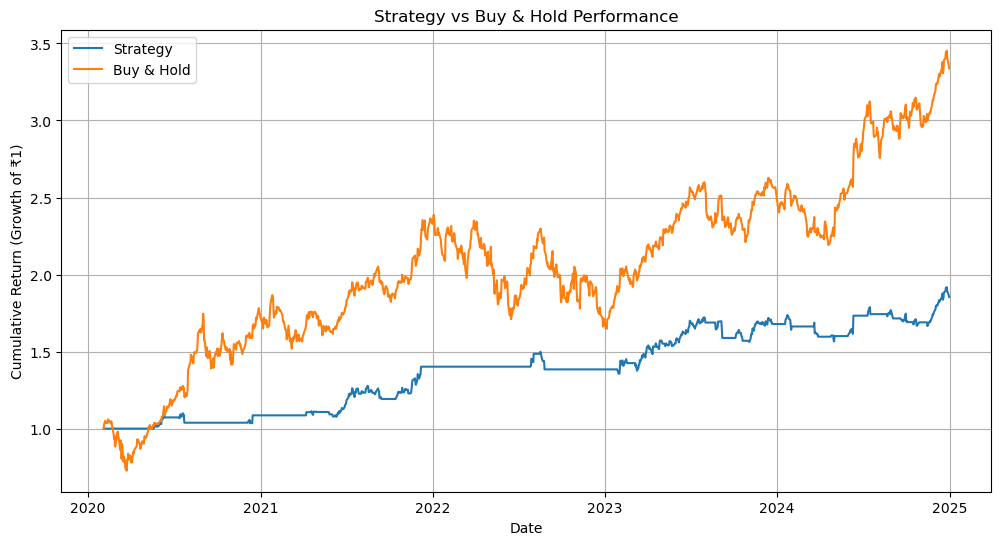

In [29]:
# Step 7, Performance Evaluation, Mean Return, Volatility, Sharpe Ratio,Cumulative Return
# =========================
# PERFORMANCE METRICS
# =========================

# Mean Return
mean_strategy = df['strategy_return'].mean()
mean_bh = df['bh_return'].mean()

# Volatility (Std Dev)
vol_strategy = df['strategy_return'].std()
vol_bh = df['bh_return'].std()

# Sharpe Ratio (assuming risk-free rate = 0)
sharpe_strategy = mean_strategy / vol_strategy
sharpe_bh = mean_bh / vol_bh

# Cumulative Return (final value - 1)
cum_strategy = df['strategy_cum'].iloc[-1] - 1
cum_bh = df['bh_cum'].iloc[-1] - 1

# =========================
# PRINT RESULTS
# =========================

print("🔹 PERFORMANCE METRICS\n")

print("Strategy:")
print("Mean Return:", mean_strategy)
print("Volatility:", vol_strategy)
print("Sharpe Ratio:", sharpe_strategy)
print("Cumulative Return:", cum_strategy)

print("\nBuy & Hold:")
print("Mean Return:", mean_bh)
print("Volatility:", vol_bh)
print("Sharpe Ratio:", sharpe_bh)
print("Cumulative Return:", cum_bh)


# =========================
# VISUAL COMPARISON
# =========================

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['strategy_cum'], label='Strategy')
plt.plot(df['Date'], df['bh_cum'], label='Buy & Hold')
plt.title('Strategy vs Buy & Hold Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Growth of ₹1)')
plt.legend()
plt.grid(True)
plt.show()
